# Gemma 4 vs VADER: Macroeconomic Sentiment Analysis
**Upgrading legacy financial datasets using state-of-the-art LLM Zero-Shot Classification**

In this notebook, we will:

* Prove why traditional sentiment analyzers (like VADER) fail at reading financial context.

* Use Gemma 4 (E4B-IT) locally on dual T4 GPUs to generate advanced macroeconomic sentiment labels (Hawkish vs. Dovish).

In [1]:
%%capture
!pip install git+https://github.com/huggingface/transformers.git accelerate -qU

In [2]:
# Basic Libs
import numpy as np 
import pandas as pd 

# Visual Libs
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown

# LLM Libs
import kagglehub
import torch
from transformers import AutoProcessor, AutoModelForCausalLM

# Utility Libs
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/models/google/gemma-4/transformers/gemma-4-e4b-it/1/config.json
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e4b-it/1/README.md
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e4b-it/1/tokenizer.json
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e4b-it/1/tokenizer_config.json
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e4b-it/1/chat_template.jinja
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e4b-it/1/model.safetensors
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e4b-it/1/processor_config.json
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e4b-it/1/generation_config.json
/kaggle/input/datasets/belbino/global-inflation-vs-interest-rates-2021-present/central_bank_rates.csv
/kaggle/input/datasets/belbino/global-inflation-vs-interest-rates-2021-present/README.md
/kaggle/input/datasets/belbino/global-inflation-vs-interest-rates-2021-present/macro_news_sentiment.csv
/kaggle/input/datasets/belbino/glob

## 1. Introduction & Data Loading
*Importing the global inflation news dataset and preparing the text features.*

In [3]:
df_news = pd.read_csv("/kaggle/input/datasets/belbino/global-inflation-vs-interest-rates-2021-present/macro_news_sentiment.csv")

In [4]:
df_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 468 entries, 0 to 467
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           468 non-null    object 
 1   title          468 non-null    object 
 2   source         468 non-null    object 
 3   sentiment      468 non-null    float64
 4   is_hawkish     468 non-null    bool   
 5   is_dovish      468 non-null    bool   
 6   description    423 non-null    object 
 7   url            423 non-null    object 
 8   published_at   468 non-null    object 
 9   sentiment_cat  468 non-null    object 
dtypes: bool(2), float64(1), object(7)
memory usage: 30.3+ KB


## 2. The Flaw of Lexicon Models (VADER)
*Analyzing the baseline `sentiment_cat` and why general sentiment fails in finance.*

In [5]:
sample_news = df_news.sample(5, random_state=42)[['date', 'title', 'sentiment_cat']]

display(sample_news)

,date,title,sentiment_cat
55,2026-03-20,"Fed Governor Waller urges caution for now, say...",negative
63,2026-03-20,"Fed’s Waller Cautious On Oil, May Advocate Rat...",negative
33,2024-04-10,US CPI beats expectations at 3.5%; June cut be...,negative
297,2026-04-10,Rhee to Leave BOK With More Guidance Tools and...,positive
72,2026-03-22,Shockwave of war is rippling through the globa...,negative


In [6]:
df_news['description'] = df_news['description'].fillna("")
df_news['full_text'] = df_news['title'] + " " + df_news['description']

sample_texts = df_news.sample(5, random_state=42)[['date', 'full_text', 'sentiment_cat']]

display(sample_texts)

,date,full_text,sentiment_cat
55,2026-03-20,"Fed Governor Waller urges caution for now, say...",negative
63,2026-03-20,"Fed’s Waller Cautious On Oil, May Advocate Rat...",negative
33,2024-04-10,US CPI beats expectations at 3.5%; June cut be...,negative
297,2026-04-10,Rhee to Leave BOK With More Guidance Tools and...,positive
72,2026-03-22,Shockwave of war is rippling through the globa...,negative


## 3. Initializing Gemma 4 E4B-IT
*Loading the 4-Billion parameter instruction-tuned model across dual T4 GPUs.*

In [7]:
print("Downloading Gemma 4 E4B-IT from Kaggle Hub")
MODEL_PATH = kagglehub.model_download("google/gemma-4/transformers/gemma-4-e4b-it")

print("Loading processor...")
processor = AutoProcessor.from_pretrained(MODEL_PATH)

print("Loading Gemma 4 onto both T4 GPUs...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    dtype=torch.bfloat16,
    device_map="auto"
)

print("Gemma 4 E4B is loaded and ready to analyze some data!")

Loading processor...
Loading Gemma 4 onto both T4 GPUs...


Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

Gemma 4 E4B is loaded and ready to analyze some data!


In [8]:
def get_gemma_sentiment(text):
    # Prompt
    messages = [
        {"role": "system", "content": "You are an expert macroeconomic analyst. Classify the sentiment of the following financial news text regarding monetary policy and inflation. Respond with exactly one of these labels: 'NEGATIVE', 'NEUTRAL', or 'POSITIVE', followed by a short, one-sentence explanation of why."},
        {"role": "user", "content": f"Text: {text}\n\nWhat is the sentiment?"}
    ]
    
    # Gemma 4 chat template
    prompt = processor.apply_chat_template(
        messages, 
        tokenize=False, 
        add_generation_prompt=True, 
        enable_thinking=False
    )
    
    # Processes the text and move it to the GPUs
    inputs = processor(text=prompt, return_tensors="pt").to(model.device)
    input_len = inputs["input_ids"].shape[-1]
    
    # Generates the prediction
    outputs = model.generate(**inputs, max_new_tokens=100, do_sample=False)
    
    # Decodes only the newly generated text
    response = processor.decode(outputs[0][input_len:], skip_special_tokens=True)
    return response.strip()


print(" VADER vs. Gemma 4 Sentiment Showdown \n")

for index, row in sample_texts.iterrows():
    print("-"*10)
    print(f" TEXT: {row['full_text']}")
    print(f" VADER Says: {row['sentiment_cat'].upper()}")
    
    # Gemma Response
    gemma_response = get_gemma_sentiment(row['full_text'])
    print("-"*10)
    print(f" GEMMA Says: {gemma_response}")
    print("-" * 10)
    print("\n" * 2)

[transformers] The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


 VADER vs. Gemma 4 Sentiment Showdown 

----------
 TEXT: Fed Governor Waller urges caution for now, says rate cuts possible later in the year Waller said in a CNBC interview that recent developments require a more conservative approach.
 VADER Says: NEGATIVE
----------
 GEMMA Says: NEUTRAL: The statement suggests a cautious approach to rate cuts, indicating uncertainty rather than a strong push for either tightening or easing.
----------



----------
 TEXT: Fed’s Waller Cautious On Oil, May Advocate Rate Cuts Later Federal Reserve Governor Christopher Waller said he is cautious about how surging oil prices on the back of the Iran war will impact inflation, though a weak job market may still call for interest-rate cuts later this year.
 VADER Says: NEGATIVE
----------
 GEMMA Says: NEUTRAL: The text presents a balanced view, acknowledging inflationary risks from oil while also suggesting potential future rate cuts due to a weak job market.
----------



----------
 TEXT: US CPI beats e

## 4. Zero-Shot Contextual Classification
*Prompting Gemma 4 to act as a macroeconomic analyst and re-classify all 468 headlines.*

In [9]:
# Updated the function for strict, single-word financial outputs
def get_strict_sentiment(text):
    messages = [
        {"role": "system", "content": "You are a highly precise macroeconomic AI. Classify the monetary policy sentiment of the following text. Respond with EXACTLY ONE WORD: 'HAWKISH', 'DOVISH', or 'NEUTRAL'. Do not provide any explanations, punctuation, or extra words."},
        {"role": "user", "content": f"Text: {text}\n\nSentiment:"}
    ]
    
    prompt = processor.apply_chat_template(
        messages, 
        tokenize=False, 
        add_generation_prompt=True, 
        enable_thinking=False
    )
    
    inputs = processor(text=prompt, return_tensors="pt").to(model.device)
    input_len = inputs["input_ids"].shape[-1]
    
    # Max token limit for output
    outputs = model.generate(**inputs, max_new_tokens=5, do_sample=False)
    response = processor.decode(outputs[0][input_len:], skip_special_tokens=True)
    
    return response.strip().upper()

print("Running Gemma 4 across all 468 headlines...")

# Progress bar for status
tqdm.pandas(desc="Analyzing Sentiment")
df_news['gemma_sentiment'] = df_news['full_text'].progress_apply(get_strict_sentiment)

print("\nAnalysis Complete! Here are the updated results:")
display(df_news[['date', 'title', 'sentiment_cat', 'gemma_sentiment']].head(10))

Running Gemma 4 across all 468 headlines...


Analyzing Sentiment:   0%|          | 0/468 [00:00<?, ?it/s]


Analysis Complete! Here are the updated results:


,date,title,sentiment_cat,gemma_sentiment
0,2021-05-12,"US CPI jumps 4.2% year over year, highest sinc...",positive,HAWKISH
1,2021-06-10,Fed insists inflation surge is transitory; no ...,negative,DOVISH
2,2021-10-13,"US CPI hits 5.4%, broadest inflation reading i...",neutral,HAWKISH
3,2021-11-03,Fed begins tapering bond purchases as inflatio...,negative,HAWKISH
4,2021-11-10,"UK CPI rises to 4.2%, Bank of England signals ...",neutral,HAWKISH
5,2021-12-15,"Fed pivots to faster taper, signals three rate...",neutral,HAWKISH
6,2022-01-12,"US CPI reaches 7%, a 40-year high, piling pres...",negative,HAWKISH
7,2022-02-03,"Bank of England raises rates to 0.5%, first ba...",neutral,HAWKISH
8,2022-02-10,Euro area inflation hits 5.1% record; ECB unde...,negative,HAWKISH
9,2022-03-16,Fed raises rates 25bps in first hike since 201...,neutral,HAWKISH


In [10]:
df_news.to_csv('macro_news_with_gemma_sentiment.csv', index=False)
print("Upgraded dataset saved successfully!")

Upgraded dataset saved successfully!


## 5. Visualizing the Paradigm Shift: Lexicon vs. LLM
*Comparing the distribution of VADER's Negative/Positive vs. Gemma's Hawkish/Dovish.*

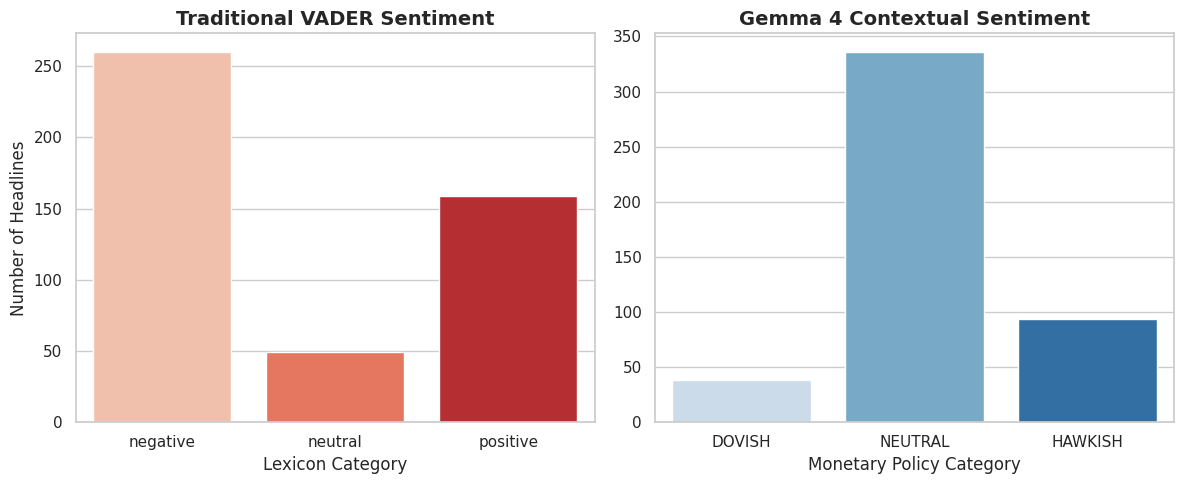

In [11]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(
    data=df_news, 
    x='sentiment_cat', 
    order=['negative', 'neutral', 'positive'], 
    palette='Reds'
)
plt.title('Traditional VADER Sentiment', fontsize=14, fontweight='bold')
plt.xlabel('Lexicon Category')
plt.ylabel('Number of Headlines')

# 2. Plot the new Gemma 4 Distribution
plt.subplot(1, 2, 2)
sns.countplot(
    data=df_news, 
    x='gemma_sentiment', 
    order=['DOVISH', 'NEUTRAL', 'HAWKISH'], 
    palette='Blues'
)
plt.title('Gemma 4 Contextual Sentiment', fontsize=14, fontweight='bold')
plt.xlabel('Monetary Policy Category')
plt.ylabel('')

plt.tight_layout()
plt.show()

## 6. The Keyword Trap: Cross-Tabulating Legacy Flags
*Testing Gemma 4's reading comprehension against the dataset's original boolean scripts.*

In [12]:
print("Comparing Gemma's Output vs. Original Dataset's 'is_hawkish' Flag")
hawkish_comparison = pd.crosstab(
    df_news['gemma_sentiment'], 
    df_news['is_hawkish'], 
    rownames=['Gemma 4 Says:'], 
    colnames=['Original is_hawkish (Bool):']
)
display(hawkish_comparison)

print("\n Comparing Gemma's Output vs. Original Dataset's 'is_dovish' Flag")
dovish_comparison = pd.crosstab(
    df_news['gemma_sentiment'], 
    df_news['is_dovish'], 
    rownames=['Gemma 4 Says:'], 
    colnames=['Original is_dovish (Bool):']
)
display(dovish_comparison)

Comparing Gemma's Output vs. Original Dataset's 'is_hawkish' Flag


Original is_hawkish (Bool):,False,True
Gemma 4 Says:,,
DOVISH,31,7
HAWKISH,59,35
NEUTRAL,327,9



 Comparing Gemma's Output vs. Original Dataset's 'is_dovish' Flag


Original is_dovish (Bool):,False,True
Gemma 4 Says:,,
DOVISH,17,21
HAWKISH,73,21
NEUTRAL,271,65


### Observations from the Comparison

When we checked the original dataset's labels against Gemma 4's reading comprehension, we found three massive problems with the old data:

1. **It missed a lot of important news:** Gemma found **59 Hawkish** headlines that the original dataset completely ignored. The old script just wasn't smart enough to catch the nuance.
2. **False Flags:** The original dataset falsely flagged **63 headlines** as Dovish just because they had words like "cut." Gemma read them and realized they were just **Neutral** updates.
3. **It was sometimes completely backwards:** There were **7 times** the original script labeled a headline as Hawkish, but Gemma realized the context was actually the exact opposite (Dovish).

## Conclusion

* Simple keyword matching is dangerously inaccurate for financial news, proving that advanced contextual AI like Gemma 4 is absolutely essential for building reliable macroeconomic datasets.